# Model 1 Loading

In [ ]:
import json, importlib
from pathlib import Path


import torch
import matplotlib.pyplot as plt
from nnsight import NNsight
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Download model definition and both sets of weights from HuggingFace
model_py_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "model.py")
spec = importlib.util.spec_from_file_location("model", model_py_path)
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)
AttentionOnlyTransformer = model_module.AttentionOnlyTransformer

# Pre-download both models so later cells don't need network access
config_1_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "config.json")
weights_1_path = hf_hub_download("andyrdt/04_2026_puzzle_1a", "model.pt")

print("Downloaded model 1.")

In [2]:
# ── Model 1 vocab (numbers 0-9, each is its own token) ──
NUM_RANGE_1 = 10
BOS_1, SEP_1, ANS_1, EOS_1 = 10, 11, 12, 13
VOCAB_SIZE_1 = 14
TOKEN_NAMES_1 = {10: "BOS", 11: "SEP", 12: "ANS", 13: "EOS"}

def tokenize_1(nums: list[int]) -> list[int]:
    """Tokenize a list of numbers for Model 1.
    Example: [3, 7, 2] -> [BOS, 3, SEP, 7, SEP, 2, ANS]"""
    tokens = [BOS_1]
    for i, n in enumerate(nums):
        tokens.append(n)
        if i < len(nums) - 1:
            tokens.append(SEP_1)
    tokens.append(ANS_1)
    return tokens

def token_labels_1(tokens: list[int]) -> list[str]:
    return [TOKEN_NAMES_1.get(t, str(t)) for t in tokens]


# ── Attention visualization ──
def _format_attn_ax(ax, attn_matrix, token_labels, title):
    """Format a single attention heatmap axis."""
    ax.imshow(attn_matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(token_labels)))
    ax.set_xticklabels(token_labels, rotation=45, ha="right",
                       rotation_mode="anchor", fontsize=7)
    ax.set_yticks(range(len(token_labels)))
    ax.set_yticklabels(token_labels, fontsize=7)
    ax.set_title(title, fontsize=10)


def plot_attention(attn_patterns, token_labels, title="Attention"):
    """Plot attention heatmaps.

    Args:
        attn_patterns: tensor of shape (n_heads, seq, seq) or list of such tensors
                       (one per layer).
        token_labels: list of strings for tick labels.
        title: plot title.
    """
    if isinstance(attn_patterns, list):
        n_layers = len(attn_patterns)
        n_heads = attn_patterns[0].shape[0]
        fig, axes = plt.subplots(n_layers, n_heads, figsize=(4 * n_heads, 3.5 * n_layers))
        if n_layers == 1:
            axes = [axes]
        for layer_idx in range(n_layers):
            attn = attn_patterns[layer_idx].detach().cpu().numpy()
            for h in range(n_heads):
                _format_attn_ax(axes[layer_idx][h], attn[h], token_labels,
                                f"L{layer_idx}H{h}")
    else:
        attn = attn_patterns.detach().cpu().numpy()
        n_heads = attn.shape[0]
        fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 3.5))
        if n_heads == 1:
            axes = [axes]
        for h in range(n_heads):
            _format_attn_ax(axes[h], attn[h], token_labels, f"H{h}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Helpers loaded.")

Helpers loaded.


---
# Model 1: Max of list (0–9), 1-layer attention-only

**Task**: Given 5 numbers from 0–9, predict the maximum.

**Input format**: `[BOS] n1 [SEP] n2 [SEP] n3 [SEP] n4 [SEP] n5 [ANS]`

**Output**: At the `[ANS]` position, the model should predict the max value. Then it should predict `[EOS]`.

**Example**: `[BOS] 3 [SEP] 7 [SEP] 2 [SEP] 5 [SEP] 1 [ANS]` → model predicts `7`

This model has a single attention layer with 4 heads and no MLPs. The entire computation is: embed → one multi-head attention layer (with residual) → unembed.

In [3]:
# Load Model 1
config_1 = json.loads(Path(config_1_path).read_text())
raw_model_1 = AttentionOnlyTransformer.from_config(config_1["model"])
raw_model_1.load_state_dict(torch.load(weights_1_path, map_location=device, weights_only=True))
raw_model_1.eval().to(device)
# `NNsight` wraps the model for tracing/interventions, but still exposes the
# underlying module tree and parameters for normal inspection.
model_1 = NNsight(raw_model_1)

print(f"Model 1 config: {config_1['model']}")
print(f"Parameters: {sum(p.numel() for p in model_1.parameters()):,}")

Model 1 config: {'vocab_size': 14, 'd_model': 64, 'n_heads': 4, 'n_layers': 1, 'max_seq_len': 12}
Parameters: 18,944


# Solution

## Logits are permutation equivariant

### Claim 1: Position vectors for the positions where the numerical tokens live are nearly identical.

Note that we have the following position layout for the input sequence:

```
pos:  0    1   2    3   4    5   6    7   8    9   10
tok: BOS  n1  SEP  n2  SEP  n3  SEP  n4  SEP  n5  ANS
```


We will verify the above claim by looking at the positional embeddings of the positions for the numerical tokens, namely positions 1, 3, 5, 7 and 9.

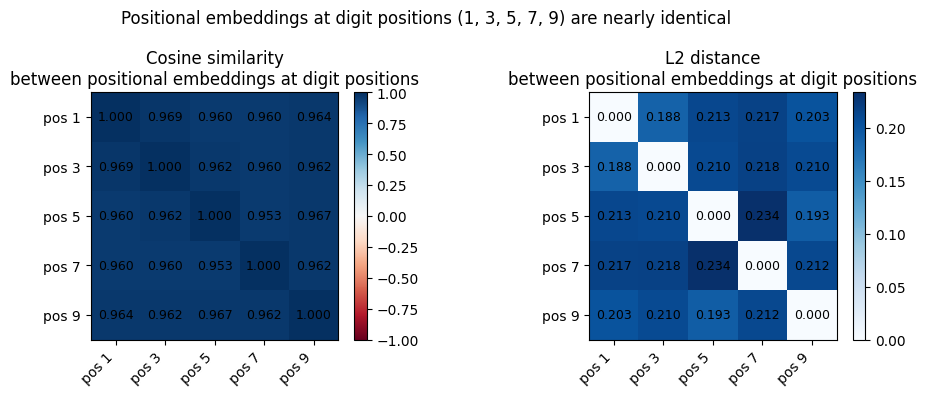

In [4]:
pos_emb = model_1.pos_embed.weight.detach()  # [max_seq_len, d_model]
DIGIT_POSITIONS = [1, 3, 5, 7, 9]
pos_labels = [f"pos {p}" for p in DIGIT_POSITIONS]
vecs = pos_emb[DIGIT_POSITIONS]  # [5, d_model]
vecs_norm = vecs / (vecs.norm(dim=-1, keepdim=True) + 1e-8)
cos_sim = (vecs_norm @ vecs_norm.T).numpy()  # [5, 5]
l2_dist = torch.cdist(vecs, vecs).numpy()  # [5, 5]

# ── Numerical summary ─────────────────────────────────────────────────────────
norms = vecs.norm(dim=-1)
off_diag_mask = ~torch.eye(len(DIGIT_POSITIONS), dtype=torch.bool)
cos_tensor = torch.tensor(cos_sim)
off_cos = cos_tensor[off_diag_mask]
l2_tensor = torch.tensor(l2_dist)
off_l2 = l2_tensor[off_diag_mask]
mean_norm = vecs.norm(dim=-1).mean().item()

# ── Plot: cosine similarity heatmap ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im = ax.imshow(cos_sim, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(pos_labels)))
ax.set_xticklabels(pos_labels, rotation=45, ha="right")
ax.set_yticks(range(len(pos_labels)))
ax.set_yticklabels(pos_labels)
for i in range(len(DIGIT_POSITIONS)):
    for j in range(len(DIGIT_POSITIONS)):
        ax.text(j, i, f"{cos_sim[i, j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Cosine similarity\nbetween positional embeddings at digit positions")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im2 = ax.imshow(l2_dist, cmap="Blues")
ax.set_xticks(range(len(pos_labels)))
ax.set_xticklabels(pos_labels, rotation=45, ha="right")
ax.set_yticks(range(len(pos_labels)))
ax.set_yticklabels(pos_labels)
for i in range(len(DIGIT_POSITIONS)):
    for j in range(len(DIGIT_POSITIONS)):
        ax.text(j, i, f"{l2_dist[i, j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("L2 distance\nbetween positional embeddings at digit positions")
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    "Positional embeddings at digit positions (1, 3, 5, 7, 9) are nearly identical",
    fontsize=12,
)
plt.tight_layout()


## Ranking of the attention weights at the ans token for all four heads

Since the final output of the model is the unembedding matrix applied to the OV output of the ans token, it suffices to look at the OV output at position 10 (ans token lives here). 

Also, although it was not necessary to plot the bars for all odd positions, it reconfirms claim 1 which says that the QK circuit output is permutation equivariant. 

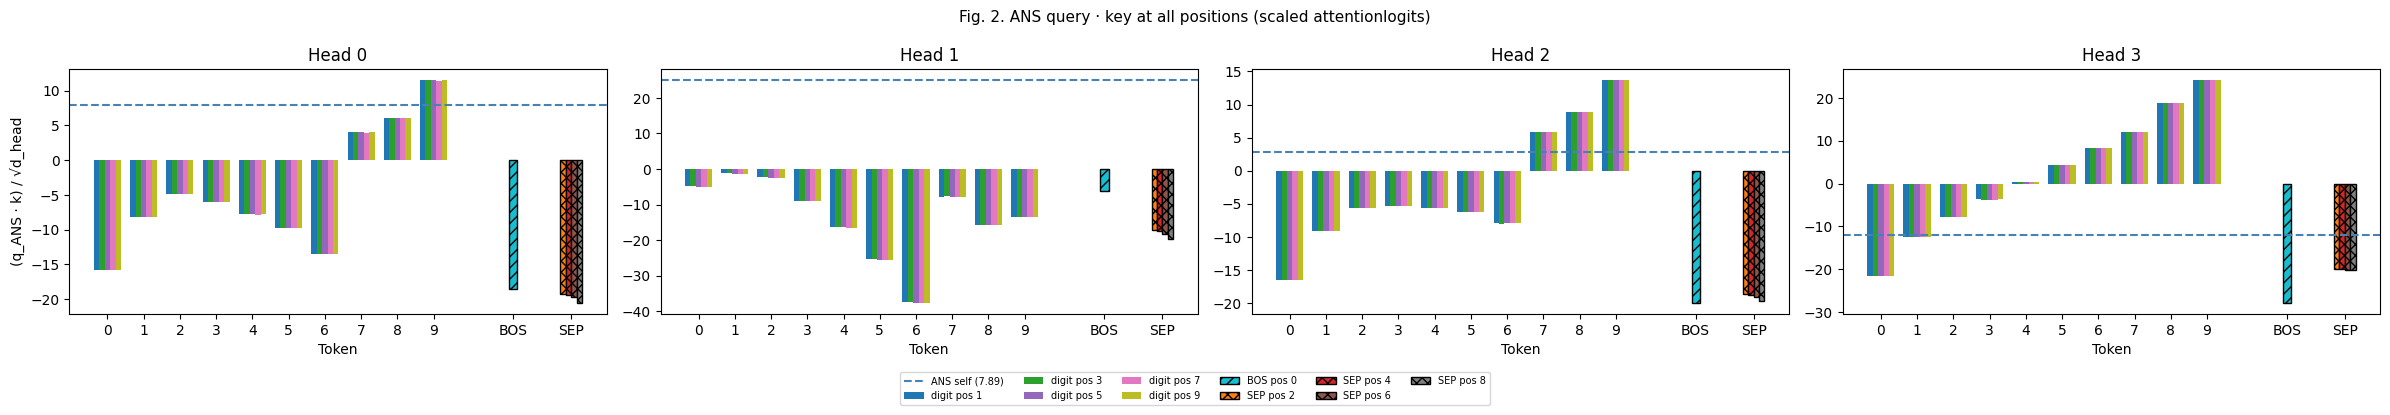

In [5]:
tok_emb = model_1.tok_embed.weight.detach()
pos_emb = model_1.pos_embed.weight.detach()
layer = model_1.layers[0]
n_heads = layer.n_heads
d_head = layer.d_head
NUM_RANGE = 10
num_tokens = list(range(NUM_RANGE))
ANS_POS = 10
DIGIT_POSITIONS = [1, 3, 5, 7, 9]
SEP_POSITIONS   = [2, 4, 6, 8]
BOS_POS = 0
ANS = NUM_RANGE + 2   # 12
BOS = NUM_RANGE       # 10
SEP = NUM_RANGE + 1   # 11

ans_residual = tok_emb[ANS] + pos_emb[ANS_POS]
scale = d_head ** 0.5

pos_colors = {
    0: "#17becf",
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd",
    6: "#8c564b",
    7: "#e377c2",
    8: "#7f7f7f",
    9: "#bcbd22",
}

X_BOS = NUM_RANGE + 1.2
X_SEP = NUM_RANGE + 2.8
bar_width = 0.15

fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 4), sharey=False)
if n_heads == 1:
    axes = [axes]

for h, head in enumerate(layer.heads):
    with torch.no_grad():
        q_ans = head.W_Q(ans_residual.unsqueeze(0))[0]
        k_ans = head.W_K(ans_residual.unsqueeze(0))[0]
    ans_logit = (q_ans * k_ans).sum().item() / scale

    ax = axes[h]

    # --- digit tokens at each digit position ---
    for pi, pos in enumerate(DIGIT_POSITIONS):
        logits = []
        for d in num_tokens:
            key_res = tok_emb[d] + pos_emb[pos]
            with torch.no_grad():
                k_d = head.W_K(key_res.unsqueeze(0))[0]
            logits.append((q_ans * k_d).sum().item() / scale)
        offsets = [xi + (pi - 2) * bar_width for xi in range(NUM_RANGE)]
        ax.bar(offsets, logits, width=bar_width, color=pos_colors[pos],
label=f"digit pos {pos}")

    # --- BOS token ---
    bos_res = tok_emb[BOS] + pos_emb[BOS_POS]
    with torch.no_grad():
        k_bos = head.W_K(bos_res.unsqueeze(0))[0]
    bos_logit = (q_ans * k_bos).sum().item() / scale
    ax.bar(X_BOS, bos_logit, width=bar_width * 1.5, color=pos_colors[0],
            edgecolor="black", hatch="///", label="BOS pos 0")

    # --- SEP token at each sep position ---
    for pi, pos in enumerate(SEP_POSITIONS):
        sep_res = tok_emb[SEP] + pos_emb[pos]
        with torch.no_grad():
            k_sep = head.W_K(sep_res.unsqueeze(0))[0]
        sep_logit = (q_ans * k_sep).sum().item() / scale
        offset = X_SEP + (pi - 1.5) * bar_width
        ax.bar(offset, sep_logit, width=bar_width, color=pos_colors[pos],
                edgecolor="black", hatch="xxx", label=f"SEP pos {pos}")

    ax.axhline(ans_logit, color="steelblue", lw=1.5, linestyle="--",
label=f"ANS self ({ans_logit:.2f})")

    xtick_pos    = list(range(NUM_RANGE)) + [X_BOS, X_SEP]
    xtick_labels = [str(d) for d in num_tokens] + ["BOS", "SEP"]
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels)
    ax.set_title(f"Head {h}")
    ax.set_xlabel("Token")
    if h == 0:
        ax.set_ylabel("(q_ANS · k) / √d_head")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=7, loc="lower center",
            ncol=6, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Fig. 2. ANS query · key at all positions (scaled attentionlogits)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

We note the following:

The attention weights (post softmax) come from the following manipulation of the raw weight (w):

$$ \frac{e^w}{\mathcal{N}} $$

where $\mathcal{N} = \sum_i{e^{w_i}}$ is the normalization factor. We note that a 1 point difference in the weight, namely $w \to w + 1$, results in the attention weight multiplied by $e$. Similarly, a 5 point difference in the weight, namely $w \to w + 5$, results in the attention weight mulitiplied by $e^5 \sim 148$. 

This observation will play a key role in our case-by-case analysis for how the model chooses the maximum.

**Example:**

Consider the input [9, 0, 0, 0, 0].
Note that for head 0, the raw attention weight between ANS and the token 9 differe by about 5 points (9 is max). Here below, notice that this results in the attenton weight (post soft-max) be concentrated almost exclusively on the token 9 (position 1):

In [6]:
nums = [9, 0, 0, 0, 0]
tokens = tokenize_1(nums)
labels = token_labels_1(tokens)

input_tensor = torch.tensor(tokens)          # [seq_len]
seq_len = len(tokens)

tok_emb = model_1.tok_embed.weight.detach()  # [vocab, d_model]
pos_emb = model_1.pos_embed.weight.detach()  # [max_seq, d_model]
layer   = model_1.layers[0]
scale   = layer.d_head ** 0.5

# residual stream at input (before attention)
residual = tok_emb[input_tensor] + pos_emb[torch.arange(seq_len)]  # [seq_len,d_model]

attn_all = []
for head in layer.heads:
    with torch.no_grad():
        Q = head.W_Q(residual)  # [seq_len, d_head]
        K = head.W_K(residual)  # [seq_len, d_head]
    scores = (Q @ K.T) / scale  # [seq_len, seq_len]
    # causal mask
    causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool),
diagonal=1)
    scores = scores.masked_fill(causal_mask, float("-inf"))
    attn_all.append(torch.softmax(scores, dim=-1))  # [seq_len, seq_len]

attn_patterns = torch.stack(attn_all)  # [n_heads, seq_len, seq_len]
attn = attn_all[0]
row = attn[-1]  # ANS row
print("Head 0 — attention from ANS:")
for pos, (label, w) in enumerate(zip(labels, row.tolist())):
    bar = "█" * int(w * 40)
    print(f"  pos {pos:2d}  {label:>4s}  {w:.4f}  {bar}")

Head 0 — attention from ANS:
  pos  0   BOS  0.0000  
  pos  1     9  0.9727  ██████████████████████████████████████
  pos  2   SEP  0.0000  
  pos  3     0  0.0000  
  pos  4   SEP  0.0000  
  pos  5     0  0.0000  
  pos  6   SEP  0.0000  
  pos  7     0  0.0000  
  pos  8   SEP  0.0000  
  pos  9     0  0.0000  
  pos 10   ANS  0.0273  █


---
## Case 1: 9 is the maximum in the input sequence

Looking at Figure 2, we make the following observations:
- Head 0 assigns the highest attention weight to token 9 (at least a 5 point difference between the first and the second).
- Head 1 assigns the highest attention weight to the ans token itself.
- Head 2 assigns the highest attention weight to token 9 (at least 5 points away from the second max)
- Head 3 assings the highest attention weight to token 9 (at least 5 points away from the second max)

Hence the concatenated vector for the ANS token position after the QK circuit looks like the following:


$$ \begin{equation} 
\Big( \langle 9 \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle 9 \rangle_{value} \quad \langle 9 \rangle_{value}\Big)
\end{equation}$$

In equation (1), the notation $\langle \text{token}\rangle_{value} $ denotes the value vector of the token.

In the cell below, we verify that for the vector in equation (1), the application of the $W_O$ matrix followed by the unembedding matrix $W_U$ results in the highest logit being assinged to the token 9 which is the required answer:

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
  -213.121-188.744-142.982 -78.386  -5.858  68.013 133.187  75.810 135.657 155.052-117.120-115.088-119.233  54.863

Predicted token: 9


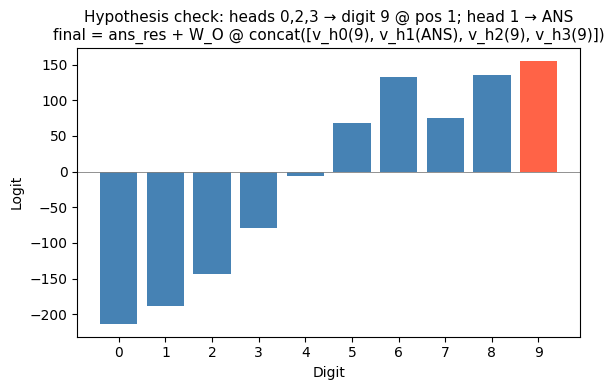

In [7]:
NUM_RANGE = 10
TOKEN_NAMES = {i: str(i) for i in range(NUM_RANGE)}
TOKEN_NAMES.update({NUM_RANGE: "BOS", NUM_RANGE + 1: "SEP", NUM_RANGE + 2: "ANS", NUM_RANGE + 3: "EOS"})
ANS = NUM_RANGE + 2
ANS_POS = 10
DIGIT_9 = 9
DIGIT_9_POS = 1
                   
layer = model_1.layers[0]
W_O_full = layer.W_O.weight.detach()   # [d_model, d_model]
d_model = model_1.d_model
n_heads = model_1.n_heads
d_head = layer.d_head

tok_emb = model_1.tok_embed.weight.detach()   # [vocab_size, d_model]
pos_emb = model_1.pos_embed.weight.detach()   # [max_seq_len, d_model]
W_U = model_1.unembed.weight.detach()         # [vocab_size, d_model]

ans_res = tok_emb[ANS]     + pos_emb[ANS_POS]      # [d_model]
res_9   = tok_emb[DIGIT_9] + pos_emb[DIGIT_9_POS]  # [d_model]

# heads 0,2,3 → digit 9; head 1 → ANS
head_inputs = [res_9, ans_res, res_9, res_9]
head_vals = []
for h, head in enumerate(layer.heads):
    with torch.no_grad():
        v = head.W_V(head_inputs[h].unsqueeze(0))[0]  # [d_head]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Logits ────────────────────────────────────────────────────────────────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]
print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_9 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")
ax.set_title(
    "Hypothesis check: heads 0,2,3 → digit 9 @ pos 1; head 1 → ANS\n"
    "final = ans_res + W_O @ concat([v_h0(9), v_h1(ANS), v_h2(9), v_h3(9)])",
    fontsize=11
)
plt.tight_layout()


---
## Case 2: 8 is the maximum in the input sequence

Looking at Figure 2, we make the following observations:
- Head 0 assigns the highest attention weight to token ANS (at least a 5 point difference between the first and the second).
- Head 1 assigns the highest attention weight to the ans token itself.
- Head 2 assigns the highest attention weight to token 8 (at least 5 points away from the second max)
- Head 3 assings the highest attention weight to token 8 (at least 5 points away from the second max)

Hence the concatenated vector for the ANS token position after the QK circuit looks like the following:


$$ \begin{equation} 
\Big( \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle 8 \rangle_{value} \quad \langle 8 \rangle_{value}\Big)
\end{equation}$$

In equation (1), the notation $\langle \text{token}\rangle_{value} $ denotes the value vector of the token.

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
  -203.518-133.006 -66.091   4.195  62.689 109.295 119.976 132.614 141.579 104.313 -89.512 -88.095 -90.546 -41.806

Predicted token: 8


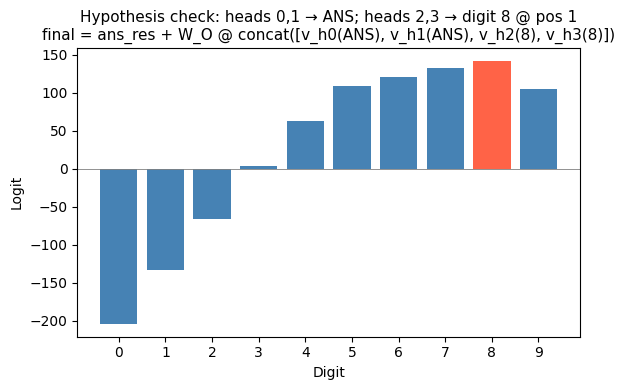

In [8]:
DIGIT_8 = 8
DIGIT_8_POS = 1
ans_res    = tok_emb[ANS]    + pos_emb[ANS_POS]    # [d_model]
res_8      = tok_emb[DIGIT_8] + pos_emb[DIGIT_8_POS]  # [d_model]

# Compute value vectors per head
head_inputs = [ans_res, ans_res, res_8, res_8]  # heads 0,1 → ANS; heads 2,3 → digit 8
head_vals = []
for h, head in enumerate(layer.heads):
    with torch.no_grad():
        v = head.W_V(head_inputs[h].unsqueeze(0))[0]  # [d_head]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Logits ────────────────────────────────────────────────────────────────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]
print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_8 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")
ax.set_title(
    "Hypothesis check: heads 0,1 → ANS; heads 2,3 → digit 8 @ pos 1\n"
    "final = ans_res + W_O @ concat([v_h0(ANS), v_h1(ANS), v_h2(8), v_h3(8)])",
    fontsize=11
)
plt.tight_layout()


---
## Case 3: 7 is the maximum in the input sequence

Since the analysis for this case follows the same pattern as the case when 8 is the maximum, we will just plot the logits below in this cell.

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
   -92.460 -38.122   3.203  39.536  60.907  71.085  51.518  89.620  70.823  27.994 -30.154 -29.716 -30.268 -64.222

Predicted token: 7


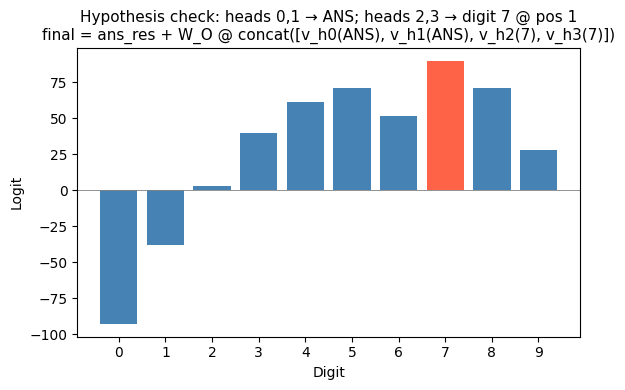

In [9]:
DIGIT_7 = 7
DIGIT_7_POS = 1

ans_res = tok_emb[ANS]     + pos_emb[ANS_POS]      # [d_model]
res_7   = tok_emb[DIGIT_7] + pos_emb[DIGIT_7_POS]  # [d_model]

# heads 0,1 → ANS; heads 2,3 → digit 7
head_inputs = [ans_res, ans_res, res_7, res_7]
head_vals = []
for h, head in enumerate(layer.heads):
    with torch.no_grad():
        v = head.W_V(head_inputs[h].unsqueeze(0))[0]  # [d_head]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Logits ────────────────────────────────────────────────────────────────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]
print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_7 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")
ax.set_title(
    "Hypothesis check: heads 0,1 → ANS; heads 2,3 → digit 7 @ pos 1\n"
    "final = ans_res + W_O @ concat([v_h0(ANS), v_h1(ANS), v_h2(7), v_h3(7)])",
    fontsize=11
)
plt.tight_layout()


---
## Case 4: 6 is the maximum in the input sequence

Looking at Figure 2, we make the following observations:
- Head 0 assigns the highest attention weight to token ANS (at least a 5 point difference between the first and the second).
- Head 1 assigns the highest attention weight to the ANS token itself.
- Head 2 assigns the highest attention weight to token ANS (at least 5 points away from the second max)
- Head 3 assings the highest attention weight to token 6 (at least 5 points away from the second max)

Hence the concatenated vector for the ANS token position after the QK circuit looks like the following:


$$ \begin{equation} 
\Big( \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle 6 \rangle_{value}\Big)
\end{equation}$$

In equation (1), the notation $\langle \text{token}\rangle_{value} $ denotes the value vector of the token.

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
  -316.339-173.948 -51.271  66.599 158.772 211.409 227.540 188.227 202.674 126.004-118.297-116.012-120.463-124.807

Predicted token: 6


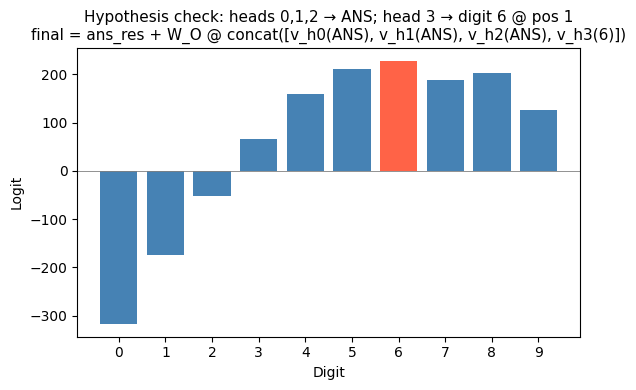

In [10]:
DIGIT_6 = 6
DIGIT_6_POS = 1
ans_res  = tok_emb[ANS]    + pos_emb[ANS_POS]       # [d_model]
res_6    = tok_emb[DIGIT_6] + pos_emb[DIGIT_6_POS]  # [d_model]

# heads 0,1,2 → ANS; head 3 → digit 6
head_inputs = [ans_res, ans_res, ans_res, res_6]
head_vals = []
for h, head in enumerate(layer.heads):
    with torch.no_grad():
        v = head.W_V(head_inputs[h].unsqueeze(0))[0]  # [d_head]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Cosine similarity of final with each token's unembedding vector ───────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]

print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_6 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_title("Logits: W_U[d] · final residual")
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")

ax.set_title(
    "Hypothesis check: heads 0,1,2 → ANS; head 3 → digit 6 @ pos 1\n"
    "final = ans_res + W_O @ concat([v_h0(ANS), v_h1(ANS), v_h2(ANS), v_h3(6)])",
    fontsize=11
)
plt.tight_layout()


## Case 5: 5, 4, 3 and 2 are the maximums respectively

All these cases have the same pattern as above, when the maximum is 6 in the input sequence. We have

$$ \begin{equation} 
\Big( \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle \text{token} \rangle_{value}\Big)
\end{equation}$$

where token is one of 5, 4, 3, or 2. We will plot the logits for these cases below

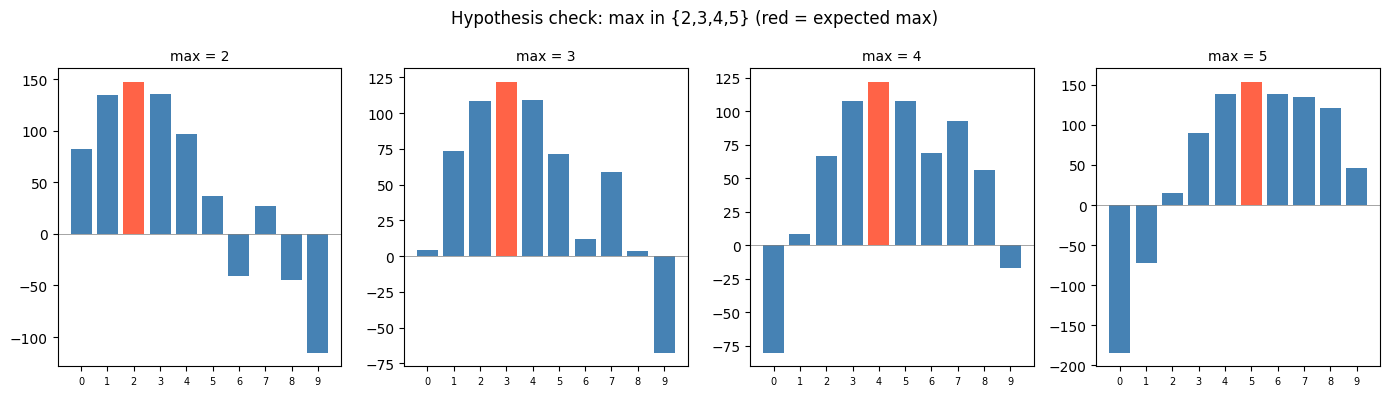

In [11]:
NUM_RANGE = 10
ANS = 12
ANS_POS = 10
DIGIT_POS = 1

layer = raw_model_1.layers[0]
tok_emb = raw_model_1.tok_embed.weight.detach()
pos_emb = raw_model_1.pos_embed.weight.detach()
W_U     = raw_model_1.unembed.weight.detach()

ans_res   = tok_emb[ANS] + pos_emb[ANS_POS]
digit_res = [tok_emb[n] + pos_emb[DIGIT_POS] for n in range(NUM_RANGE)]

def compute_logits(head_inputs):
    head_vals = []
    for h, head in enumerate(layer.heads):
        with torch.no_grad():
            v = head.W_V(head_inputs[h].unsqueeze(0))[0]
        head_vals.append(v)
    concat_v = torch.cat(head_vals)
    attn_out = layer.W_O.weight @ concat_v
    final    = ans_res + attn_out
    return (W_U @ final).detach().numpy()

# Head inputs per digit hypothesis
A = ans_res
head_inputs_per_digit = {
0: [A, A, A, A],
1: [A, A, A, 0.5 * digit_res[1] + 0.5 * A],
2: [A, A, A, digit_res[2]],
3: [A, A, A, digit_res[3]],
4: [A, A, A, digit_res[4]],
5: [A, A, A, digit_res[5]],
6: [A, A, A, digit_res[6]],
7: [A, A, digit_res[7], digit_res[7]],
8: [A, A, digit_res[8], digit_res[8]],
9: [digit_res[9], A, digit_res[9], digit_res[9]],
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, n in zip(axes, [2, 3, 4, 5]):
      logits = compute_logits(head_inputs_per_digit[n])
      colors = ["tomato" if d == n else "steelblue" for d in range(NUM_RANGE)]
      ax.bar(range(NUM_RANGE), logits[:NUM_RANGE], color=colors)
      ax.axhline(0, color="gray", lw=0.5)
      ax.set_title(f"max = {n}", fontsize=10)
      ax.set_xticks(range(NUM_RANGE))
      ax.set_xticklabels([str(i) for i in range(NUM_RANGE)], fontsize=7)

plt.suptitle("Hypothesis check: max in {2,3,4,5} (red = expected max)",
fontsize=12)
plt.tight_layout()
plt.show()

---
## Case 6: 1 is the maximum in the input sequence

Looking at Figure 2, we make the following observations:
- Head 0 assigns the highest attention weight to token ANS (at least a 5 point difference between the first and the second).
- Head 1 assigns the highest attention weight to the ANS token itself.
- Head 2 assigns the highest attention weight to token ANS (at least 5 points away from token 1)
- Head 3 assigns almost equal weights to ANS token and the token 1.

Hence the concatenated vector for the ANS token position after the QK circuit looks like the following:

$$ \begin{equation} 
\Big( \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle 8 \rangle_{value} \quad  0.5 \cdot \langle 1 \rangle_{value} + 0.5 \cdot \langle \text{ANS}\rangle_{value}\Big)
\end{equation}$$

Feeding this vector through the $W_O$ matrix and then the unembedding matrix results in the highest logit belonging to the token 1 as required:

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
   230.141 247.995 220.640 160.834  73.596 -27.912-140.163 -32.980-136.708-204.237 148.241 145.806 150.740-149.373

Predicted token: 1


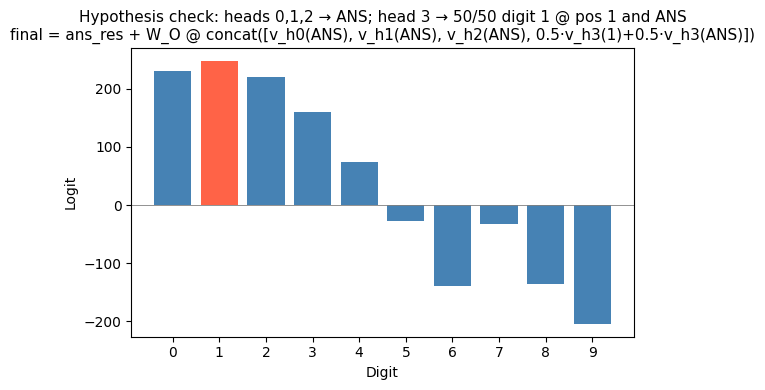

In [12]:
DIGIT_1 = 1
DIGIT_1_POS = 1


ans_res  = tok_emb[ANS]    + pos_emb[ANS_POS]       # [d_model]
res_1    = tok_emb[DIGIT_1] + pos_emb[DIGIT_1_POS]  # [d_model]

# Heads 0,1,2 → ANS; head 3 → 50/50 digit 1 and ANS
head_inputs = [ans_res, ans_res, ans_res, None]
head_vals = []
for h, head in enumerate(layer.heads):
    with torch.no_grad():
        if h < 3:
            v = head.W_V(ans_res.unsqueeze(0))[0]
        else:
            v = 0.5 * head.W_V(res_1.unsqueeze(0))[0] + 0.5 * head.W_V(ans_res.unsqueeze(0))[0]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Logits ────────────────────────────────────────────────────────────────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]
print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_1 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")
ax.set_title(
    "Hypothesis check: heads 0,1,2 → ANS; head 3 → 50/50 digit 1 @ pos 1 and ANS\n"
    "final = ans_res + W_O @ concat([v_h0(ANS), v_h1(ANS), v_h2(ANS), 0.5·v_h3(1)+0.5·v_h3(ANS)])",
    fontsize=11
)
plt.tight_layout()


# Case 7: 0 is the maximum in the input sequence

In this case all heads attend to the ANS token itself with a large margin. Here the concatenated value vector looks like:

$$ \begin{equation} 
\Big( \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \quad \langle \text{ANS} \rangle_{value} \Big)
\end{equation}$$

In this case the model assigns the highest logit to the token 0:

Dot product of final residual with each token's unembedding vector:
         0       1       2       3       4       5       6       7       8       9     BOS     SEP     ANS     EOS
   363.501 350.962 286.977 183.817  52.796 -86.322-229.899 -86.942-219.501-284.778 213.280 209.696 216.915-155.354

Predicted token: 0


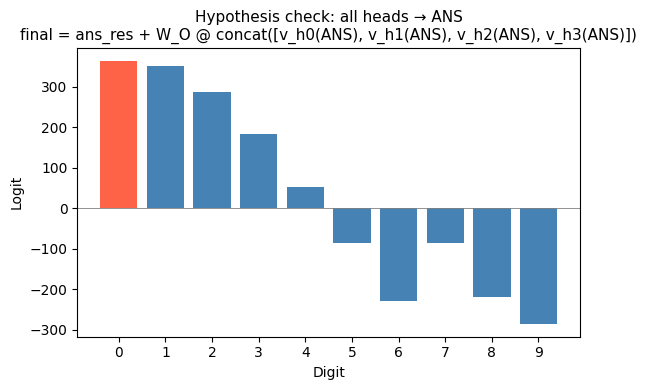

In [13]:
DIGIT_0 = 0

ans_res = tok_emb[ANS] + pos_emb[ANS_POS]  # [d_model]

# All heads attend to ANS
head_vals = []
for head in layer.heads:
    with torch.no_grad():
        v = head.W_V(ans_res.unsqueeze(0))[0]  # [d_head]
    head_vals.append(v)

concat_v = torch.cat(head_vals)          # [d_model]
attn_out  = W_O_full @ concat_v          # [d_model]
final     = ans_res + attn_out           # [d_model]

# ── Logits ────────────────────────────────────────────────────────────────────
token_labels = [TOKEN_NAMES[i] for i in range(len(TOKEN_NAMES))]
vocab_size = W_U.shape[0]

logits = (W_U @ final).detach().numpy()  # [vocab_size]
print("Dot product of final residual with each token's unembedding vector:")
print("  " + "".join(f"{token_labels[i]:>8}" for i in range(vocab_size)))
print("  " + "".join(f"{logits[i]:>8.3f}" for i in range(vocab_size)))
print(f"\nPredicted token: {token_labels[int(logits[:NUM_RANGE].argmax())]}")

# ── Bar chart of logits for digit tokens ──────────────────────────────────────
digit_labels = [str(d) for d in range(NUM_RANGE)]
digit_logits = logits[:NUM_RANGE]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(digit_labels, digit_logits, color=["tomato" if d == DIGIT_0 else "steelblue" for d in range(NUM_RANGE)])
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("Digit")
ax.set_ylabel("Logit")
ax.set_title(
    "Hypothesis check: all heads → ANS\n"
    "final = ans_res + W_O @ concat([v_h0(ANS), v_h1(ANS), v_h2(ANS), v_h3(ANS)])",
    fontsize=11
)
plt.tight_layout()


---
# Head 1 can be ablated

From Fig. 2, it is clear that head 1 attends to the ANS token itself irrespective of the input. This points to the fact that head 1 can be ablated. We verify this below:

In [14]:
def accuracy_ablate_heads(model, ablate_heads, n_trials=2000, seed=42):
    torch.manual_seed(seed)
    correct = 0
    for _ in range(n_trials):
        nums = torch.randint(0, NUM_RANGE, (5,)).tolist()
        tokens = tokenize_1(nums)
        x = torch.tensor([tokens])
        s = len(tokens)
        positions = torch.arange(s).unsqueeze(0)
        with torch.no_grad():
            h = model.tok_embed(x) + model.pos_embed(positions)
            mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
            for layer_module in model.layers:
                head_outs = []
                for hi, head in enumerate(layer_module.heads):
                    out, _ = head(h, mask)
                    head_outs.append(torch.zeros_like(out) if hi in ablate_heads else out)
                attn_out = layer_module.W_O(torch.cat(head_outs, dim=-1))
                h = h + attn_out
            logits = model.unembed(h)[0, -1, :NUM_RANGE]
        if logits.argmax().item() == max(nums):
            correct += 1
    return correct / n_trials

acc_full     = accuracy_ablate_heads(model_1, ablate_heads=[])
acc_no_head1 = accuracy_ablate_heads(model_1, ablate_heads=[1])

print(f"\nAccuracy (all heads) on 5000 random inputs:       {acc_full:.4f}")
print(f"Accuracy (head 1 ablated) on 5000 random inputs:  {acc_no_head1:.4f}")


Accuracy (all heads) on 5000 random inputs:       1.0000
Accuracy (head 1 ablated) on 5000 random inputs:  1.0000
